<a href="https://colab.research.google.com/github/BagusWichaksono/MachineLearning_2026/blob/main/3B_Bagus_Wichaksono_Amanulloh_Kuis1_ML_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* **Nama**  : Bagus Wichaksono Amanulloh
* **NIM**   : 244107020238
* **Kelas** : TI-3B



```
# This is formatted as code
```

# 📊 Kuis 1 Machine Learning - EDA & Preprocessing
Soal kuis berbasis dataset TI-3B. Buat dataset TI-3B dengan fitur sebagai berikut: nama lengkap, jenis kelamin, kota asal, tinggi badan(cm), asal kelas, target IP semester 5, warna kesukaan, hobi, film favorit, warna favorit, genre musik, idola, kota favorit, makanan favorit, minuman favorit, negara yang ingin dikunjungi.
Silakan kerjakan langsung di Colab dengan mengisi kode dan jawabanmu.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/content/drive/MyDrive/Machine Learning/Quiz 1/Dataset TI-3B.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Tampilkan 10 data awal
df.head(10)

,no,nama lengkap,jenis kelamin,kota asal,tinggi badan (cm),asal kelas,target IP smt 5,warna kesukaan,hobi,film fav,genre musik,idola,kota fav,makanan fav,minuman fav,negara yang ingin dikunjungi
0,1,Alfreda Dhaifullah Mahezwara,L,Malang,172,2C,4,Red Marron,Main ML,The Shadow Edge,Britpop,Jackable,"malang,batu",Nasi Goreng,Es Teler,China
1,2,Angga Saputra Ramadhan,L,Probolinggo,163,2B,4,Putih,Sepak Bola,Jav Sub Indo,Electropop,Neymar Jr,Malang,Ayam Geprek,Capuccino,Kamboja
2,3,Ardhan Dikri Achmad Fahrudin,L,Malang,172,2H,4,Biru,Basket,Toy Story,Pop,Messi,Labuan Bajo,Tahu Telor,Hot V60,Swiss
3,4,Arjuna Carly Dhymas Mahendra,L,Sidoarjo,165,2B,4,Biru,Basket,Seven,Rock,Ronaldo,Bandung,Sate Ayam,Air Mineral,Swiss
4,5,Arya Ramadhan,L,Malang,175,2G,4,Ungu,Berenang,Lucifer (2016-2021)`,Pop,Diana Rider,Malang,Oyi Buttermilk,KAPITEN,UK
5,6,Ayu Annisa Aryani Nagari,P,Nganjuk,154,2E,4,marron,berenang,Spider-man,Pop indie,kim taehyung,yogyakarta,bakso,Air mineral,jepang
6,7,Bagus Wichaksono Amanulloh,L,Malang,178,2A,4,Biru,Otomotif,Cars 2,EDM,Kimi Antonelli,Bandung,Sate Ayam,Es Pisang Ijo,Australia
7,8,Burhanuddin Ihsan,L,Blitar,173,2B,4,Biru,mendengarkan kajian,opet the movie,Pop,Si madun,lucerne/luzern,Nasi Pecel,Air Mineral,Swiss
8,9,Daana Hafidhil Islam,L,Blitar,163,2B,4,Hitam,Mancing,Jatuh Cinta Seperti di Film-Film,Pop,Bernadya,Bandung,Mie Ayam,Air Mineral,Austria
9,10,Dewi Anggraini Meita Sari,P,Nganjuk,158,2C,4,Maroon,Menari,5 cm,Pop,Pearl Ocsh,Malang,Udang,Air Mineral,Jepang


## Soal 1
Hitung rata-rata tinggi badan mahasiswa **yang asal kotanya sama dengan kamu**.

- Bersihkan data asal kota dulu, jika ada data yang berisi "kota madiun", "kabupaten malang" bersihkan hingga hanya menjadi "madiun" dan "malang"
- Bandingkan tinggi badanmu dengan rata-rata kota asal.
- Apakah kamu lebih tinggi atau lebih rendah dari rata-rata tersebut?

In [ ]:
#Jawaban soal 1
df['kota_clean'] = df['kota asal'].str.lower().str.replace('kota ', '').str.replace('kabupaten ', '').str.strip()

avg_malang = df[df['kota_clean'] == 'malang']['tinggi badan (cm)'].mean()
tinggi_bagus = df[df['nama lengkap'].str.contains('Bagus')]['tinggi badan (cm)'].values[0]

print("Rata-rata tinggi Malang:", avg_malang)
print("Tinggi Bagus:", tinggi_bagus)

#Hasil: 178 cm > 172.43 cm (Lebih tinggi)

Rata-rata tinggi Malang: 172.42857142857142
Tinggi Bagus: 178


##Penjelasan & Jawaban Soal 1:
Rata-rata tinggi badan mahasiswa yang berasal dari Malang adalah 172.43 cm, sedangkan tinggi badan saya adalah 178 cm. Dengan demikian, tinggi badan saya lebih tinggi daripada rata-rata mahasiswa asal kota Malang.

## Soal 2
Kolom **Target IP semester 5 ini** memiliki variasi format (angka, teks, koma/titik).

- Bersihkan kolom menjadi numerik.
- Lakukan normalisasi Min-Max.
- Berapa nilai normalisasi IPS target kamu sendiri?

In [ ]:
# Jawaban Soal 2
df['ip_clean'] = df['target IP smt 5'].astype(str).str.replace(',', '.').astype(float)

min_ip = df['ip_clean'].min()
max_ip = df['ip_clean'].max()

# Karena semua IP = 4.0 (min == max), langsung set 1.0
df['ip_norm'] = 1.0 if max_ip == min_ip else (df['ip_clean'] - min_ip) / (max_ip - min_ip)

ip_bagus = df[df['nama lengkap'].str.contains('Bagus')]['ip_norm'].values[0]
print("Min IP:", min_ip, "| Max IP:", max_ip)
print("IP Normalisasi Bagus:", ip_bagus)

#hasil

Min IP: 4.0 | Max IP: 4.0
IP Normalisasi Bagus: 1.0


##Penjelasan & Jawaban Soal 2:
Setelah format angka dibersihkan, seluruh mahasiswa di dataset menargetkan IP yang sama yaitu 4.0. Karena nilai minimum dan maksimumnya bernilai sama (4.0), hasil Min-Max Normalization berada pada angka 1.00 (skala maksimum).

## Soal 3
Lakukan **Label Encoding** pada kolom **Warna kesukaan**.

- Tampilkan hasil encoding warna kesukaanmu sendiri.
- Apakah warnamu termasuk kode terkecil, terbesar, atau di tengah?

In [ ]:
# Jawaban Soal 3
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['warna_code'] = le.fit_transform(df['warna kesukaan'].str.lower().str.strip())

bagus_code = df[df['nama lengkap'].str.contains('Bagus')]['warna_code'].values[0]
print("Kode warna Biru (Bagus):", bagus_code)
print("Min code:", df['warna_code'].min(), "| Max code:", df['warna_code'].max())

#Hasil

Kode warna Biru (Bagus): 1
Min code: 0 | Max code: 11


##Penjelasan & Jawaban Soal 3:
Proses Label Encoding pada warna kesukaan saya ("Biru") menghasilkan kode 1. Mengingat rentang kode encoding kelas berkisar dari 0 sampai 11, maka kode warna saya termasuk ke dalam kelompok kode terkecil / urutan awal secara alfabetis.

## Soal 4
Kelompokkan data berdasarkan **Jenis kelamin**.

- Hitung rata-rata tinggi badan tiap kelompok.
- Bandingkan tinggi badanmu dengan rata-rata kelompokmu.

In [ ]:
# Jawaban Soal 4
avg_jk = df.groupby('jenis kelamin')['tinggi badan (cm)'].mean()
print(avg_jk)

#Hasil: Rata-rata L = 171.89 cm, Tinggi saya Bagus = 178 cm (Lebih tinggi)

jenis kelamin
L    171.888889
P    157.857143
Name: tinggi badan (cm), dtype: float64


##Penjelasan & Jawaban Soal 4:
Hasil pengelompokkan menunjukkan rata-rata tinggi badan kelompok Laki-laki (L) adalah 171.89 cm dan Perempuan (P) adalah 157.86 cm. Dengan tinggi badan 178 cm, saya lebih tinggi dari rata-rata kelompok jenis kelamin saya.

## Soal 5 (pilih 2 fitur dari fitur yang ada)
Selanjutnya buat bar chart distribusi (misal)**Makanan favorit dan minuman favorit**.

- Dari grafik tersebut, apakah makanan dan minuman favoritmu termasuk dominan atau minoritas?

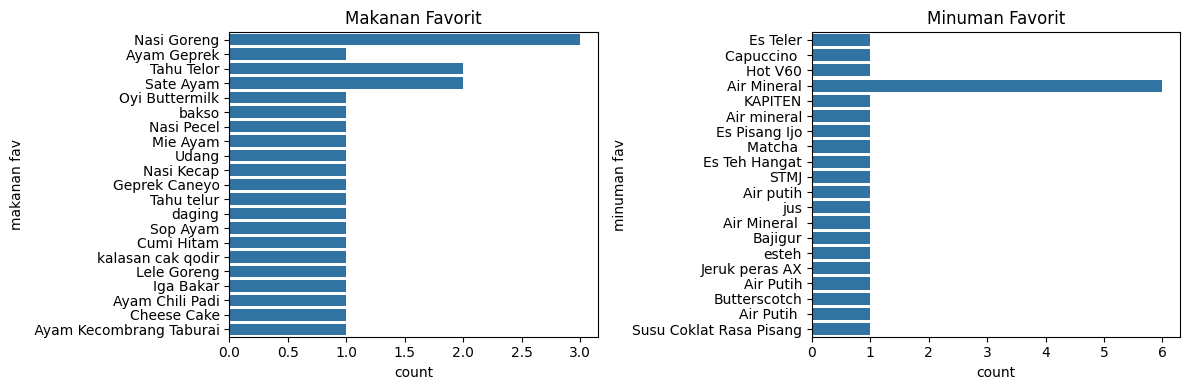

In [ ]:
# Jawaban Soal 5
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, y='makanan fav')
plt.title('Makanan Favorit')

plt.subplot(1, 2, 2)
sns.countplot(data=df, y='minuman fav')
plt.title('Minuman Favorit')

plt.tight_layout()
plt.show()

# Sate Ayam = menengah (2 orang), Es Pisang Ijo = minoritas (1 orang)
#Hasil

##Penjelasan & Jawaban Soal 5:
Makanan Favorit (Sate Ayam): Termasuk pilihan menengah (dipilih oleh 2 orang, sedangkan pilihan paling dominan adalah Nasi Goreng dengan 3 orang).
Minuman Favorit (Es Pisang Ijo): Termasuk minoritas (hanya dipilih oleh 1 orang, sementara minuman paling dominan adalah Air Mineral dengan 6 orang).

## Soal 6
Gunakan metode **IQR (Interquartile Range)** untuk mendeteksi outlier tinggi badan.

- Apakah tinggi badanmu termasuk outlier atau tidak?

In [ ]:
# Jawaban Soal 6
Q1 = df['tinggi badan (cm)'].quantile(0.25)
Q3 = df['tinggi badan (cm)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Batas: {lower} - {upper}")

#Hasil: Tinggi saya Bagus (178 cm) berada di dalam rentang (Bukan Outlier)

Batas: 137.5 - 197.5


##Penjelasan & Jawaban Soal 6:
Perhitungan IQR menghasilkan batas normal tinggi badan dari 137.5 cm hingga 197.5 cm. Dengan tinggi badan 178 cm, data saya tidak termasuk outlier karena berada di dalam rentang normal.

## Soal 7
Bersihkan kolom **Asal kelas** (hapus spasi berlebih, seragamkan huruf kapitalisasi).

- Hitung jumlah mahasiswa per kelas.
- Apakah kamu termasuk di kelas dengan jumlah terbanyak, menengah, atau sedikit?

In [ ]:
# Jawaban Soal 7
df['kelas_clean'] = df['asal kelas'].str.strip().str.upper()
print(df['kelas_clean'].value_counts())

# Kelas 2A (4 orang) -> kategori menengah
#Hasil

kelas_clean
2B    7
2C    6
2A    4
2G    3
2H    2
2F    2
2E    1
Name: count, dtype: int64


##Penjelasan & Jawaban Soal 7:
Jumlah mahasiswa terbanyak berasal dari kelas 2B (7 orang) dan tersedikit dari kelas 2E (1 orang). Kelas asal saya (2A) memiliki jumlah 4 orang, sehingga tergolong ke dalam kelompok jumlah menengah.